In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
T = 30
dim = 10_000


def get_growth(mu=0.05, sigma=0):
    if sigma == 0:
        return np.ones(T) * mu

    return np.random.normal(mu, sigma, shape=(T, dim))


In [14]:
growth

array([[0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05],
       ...,
       [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, ..., 0.05, 0.05, 0.05]], shape=(30, 10000))

In [12]:
g = np.array([30]).reshape(1,30)

ValueError: cannot reshape array of size 1 into shape (1,30)

In [11]:
g = np.array([[1, 2, 3], 
              [1, 2, 4]]).reshape(2, -1)

print(g)

np.cumprod(g, axis=1)

[[1 2 3]
 [1 2 4]]


array([[1, 2, 6],
       [1, 2, 8]])

In [2]:
vermogen = 100_000

# rendement
dividend_yield = 0.02
growth_rate = 0.05

# belasting
box_3_tarief = 0.36
vpb = 0.19
box_2_tarief = 0.245
vrijstelling = 1800

# kosten
bid_ask_spread = 0.01
oprichtingskosten = 2_000
jaarlijkse_kosten = 1_000

# optimaal
# bid_ask_spread = 0
# oprichtingskosten = 0
# jaarlijkse_kosten = 0

# simulatie
n = 30

In [3]:
def get_box3():
    data = pd.DataFrame(columns=["vermogen", "bruto", "belasting", "netto"])
    data.loc[0, "vermogen"] = vermogen

    for t in range(1, n + 1):
        data.loc[t, "bruto"] = data.loc[t - 1, "vermogen"] * (
            dividend_yield + growth_rate
        )
        data.loc[t, "belasting"] = max(
            0, data.loc[t, "bruto"] * box_3_tarief - vrijstelling
        )
        data.loc[t, "netto"] = data.loc[t, "bruto"] - data.loc[t, "belasting"]

        data.loc[t, "vermogen"] = data.loc[t - 1, "vermogen"] + data.loc[t, "netto"]
    return data

In [18]:
(0.9*1.2)**0.5

1.0392304845413265

In [1]:
g = [0.90, 1.2] * 20
start = 1

r = list()
r3 = list()
v = start
v2 = start
for gg in g:
    v *= gg
    r.append(v)
    v2 *= 1.0392304845413265
    r3.append(v2)

plt.plot(r)
plt.plot(r3)


NameError: name 'plt' is not defined

In [21]:
r2= list()
for i, x in enumerate(r[1:], start=1):
    p = x ** (1/i)
    r2.append(p)

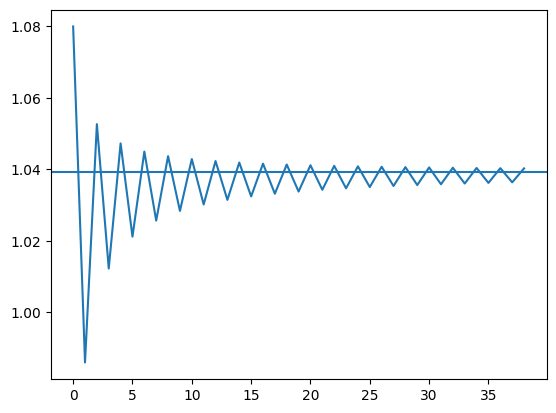

In [23]:

plt.plot(r2)
plt.axhline(1.0392304845413265)

In [47]:
np.random.lognormal(0.07, 0.1, size=(n + 1, m))

array([[1.10956512],
       [1.52265724],
       [0.9236359 ],
       [1.06371951],
       [1.07922126],
       [0.83315022],
       [0.96407261],
       [1.13404945],
       [1.15212415],
       [1.07981688],
       [1.03240959],
       [1.07808148],
       [1.33077513],
       [0.98046686],
       [1.05180967],
       [1.04308252],
       [0.91025004],
       [1.11014881],
       [1.11175642],
       [1.11486409],
       [0.96295061],
       [0.97915443],
       [0.89512822],
       [1.07797325],
       [1.00750901],
       [1.03839274],
       [1.09032897],
       [1.18155404],
       [1.17659869],
       [0.99593619],
       [1.1137263 ]])

In [ ]:
n = 30
m = 2

g = np.random.lognormal(0.0633, 0.1, size=(n + 1, m))
vermogen = 100_000
d = 0.02
a = 0.36
v = 0.19
b = 0.245





In [96]:
def get_box3():
    data = np.zeros((n + 1, m))
    data[0, :] = vermogen

    for t in range(1, n + 1):
        data[t, :] = data[t - 1, :] * (1 + (d + g[t, :] - 1) * (1 - a))
    return data

In [97]:
box3 = get_box3()

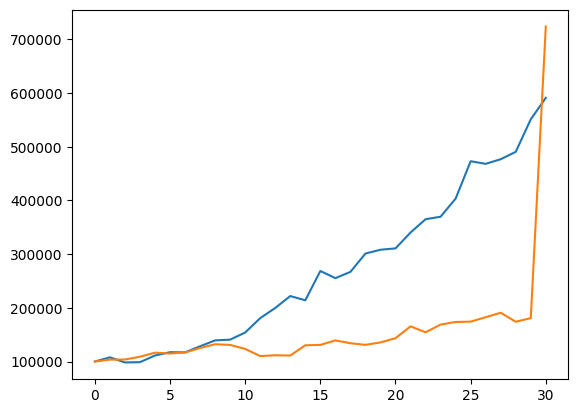

In [98]:
plt.plot(box3)

In [84]:
g

array([[0.91151066, 0.98902276],
       [1.10312379, 1.03610946],
       [0.84089616, 0.98275179],
       [0.98925402, 1.05873805],
       [1.17613091, 1.08780506],
       [1.06632435, 0.95912849],
       [0.97607593, 1.00555556],
       [1.13116914, 1.09195482],
       [1.11321143, 1.06765893],
       [0.99553143, 0.96484733],
       [1.12752732, 0.89068107],
       [1.25110679, 0.81204822],
       [1.14413514, 1.00168774],
       [1.15307774, 0.97246058],
       [0.92435234, 1.2483219 ],
       [1.37856321, 0.98840437],
       [0.90229177, 1.08085102],
       [1.05148909, 0.91994321],
       [1.17967841, 0.94527295],
       [1.01687367, 1.03360897],
       [0.99257826, 1.07060952],
       [1.12866514, 1.2208895 ],
       [1.09370228, 0.87487586],
       [1.00001045, 1.12606993],
       [1.12245543, 1.02447055],
       [1.24951143, 0.98558038],
       [0.96405914, 1.05375808],
       [1.00872612, 1.05104384],
       [1.02497498, 0.84300979],
       [1.17291393, 1.04058916],
       [1.

In [87]:
g.cumprod(axis=0)

array([[0.91151066, 0.98902276],
       [1.0055091 , 1.02473584],
       [0.84552874, 1.00706098],
       [0.83644271, 1.06621379],
       [0.98376613, 1.15983275],
       [1.04901377, 1.11242864],
       [1.02391709, 1.11860881],
       [1.15822342, 1.22147028],
       [1.28934755, 1.30411365],
       [1.28358601, 1.25827057],
       [1.44727829, 1.12071778],
       [1.8106997 , 0.91007688],
       [2.07168516, 0.91161285],
       [2.38881403, 0.88650756],
       [2.20810585, 1.10664679],
       [3.04401349, 1.09381452],
       [2.74658833, 1.18225055],
       [2.88800766, 1.08760336],
       [3.40692028, 1.02808204],
       [3.46440753, 1.06263483],
       [3.43869561, 1.13766696],
       [3.88113586, 1.38896565],
       [4.24480715, 1.21517252],
       [4.2448515 , 1.36836924],
       [4.76465664, 1.40185399],
       [5.95349292, 1.38163978],
       [5.73951926, 1.45591409],
       [5.789603  , 1.53022954],
       [5.93419825, 1.28999848],
       [6.96030377, 1.34235843],
       [7.

In [86]:
g[-1, :] = 1.07**(n) / g.cumprod(axis=0)[-2,:]
g

array([[0.91151066, 0.98902276],
       [1.10312379, 1.03610946],
       [0.84089616, 0.98275179],
       [0.98925402, 1.05873805],
       [1.17613091, 1.08780506],
       [1.06632435, 0.95912849],
       [0.97607593, 1.00555556],
       [1.13116914, 1.09195482],
       [1.11321143, 1.06765893],
       [0.99553143, 0.96484733],
       [1.12752732, 0.89068107],
       [1.25110679, 0.81204822],
       [1.14413514, 1.00168774],
       [1.15307774, 0.97246058],
       [0.92435234, 1.2483219 ],
       [1.37856321, 0.98840437],
       [0.90229177, 1.08085102],
       [1.05148909, 0.91994321],
       [1.17967841, 0.94527295],
       [1.01687367, 1.03360897],
       [0.99257826, 1.07060952],
       [1.12866514, 1.2208895 ],
       [1.09370228, 0.87487586],
       [1.00001045, 1.12606993],
       [1.12245543, 1.02447055],
       [1.24951143, 0.98558038],
       [0.96405914, 1.05375808],
       [1.00872612, 1.05104384],
       [1.02497498, 0.84300979],
       [1.17291393, 1.04058916],
       [1.

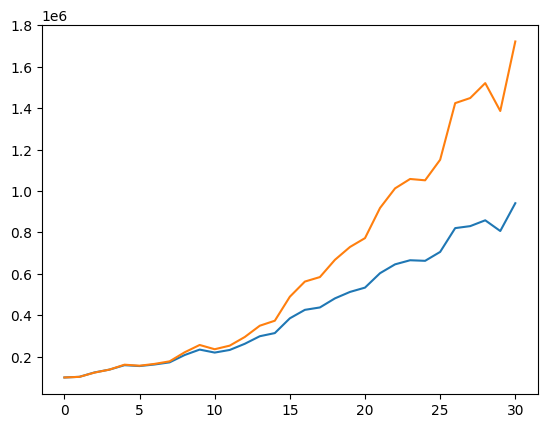

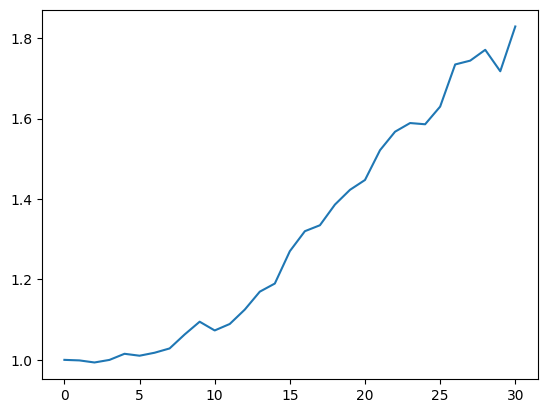

In [44]:
def get_box2_optimaal():
    data = np.zeros((n + 1, m))
    data[0, :] = vermogen

    total = np.ones(m) * vermogen
    taxed_already = np.zeros(m)

    for t in range(1, n + 1):

        taxed_already = taxed_already + total * d * (1 - v)
        total = total * (1 + g[t, :] + d * (1 - v))
        after_tax = (total - vermogen - taxed_already) * (1 - v)
        data[t, :] = vermogen + (taxed_already + after_tax) * (1 - b)
    return data


box3 = get_box3()
box2 = get_box2_optimaal()

relatief = box2 / box3

plt.plot(box3)
plt.plot(box2)
plt.show()

plt.plot(relatief)
plt.show()

In [46]:
g.shape

(31, 1)

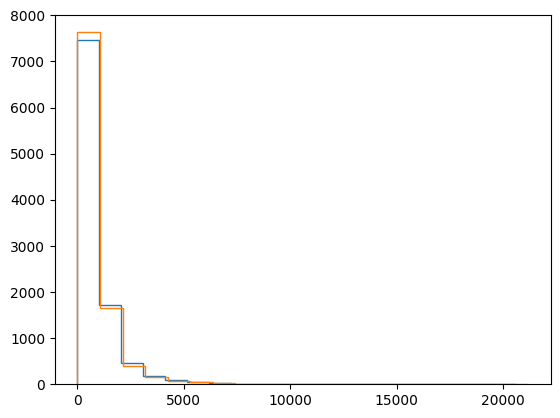

In [43]:
import numpy as np
import matplotlib.pyplot as plt

n = 100
m = 10000

x = np.random.normal(0.07, 0.1, (n, m))
x2 = np.random.lognormal(0.0633, 0.093, (n, m))
start = np.ones(m)
start2 = np.ones(m)
for i in range(n):
    start *= 1 + x[i, :]
    start2 *= x2[i, :]

plt.hist(start, bins=20, histtype='step')
plt.hist(start2, bins=20, histtype='step')
plt.show()